# Importing libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the dataset

In [2]:
titanic_data = pd.read_csv('Titanic-Dataset.csv')
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
# Check df info
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check for null values
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Since the 'Cabin' column has a large number of null values, we will drop it from the dataset
titanic_data.drop(columns=['Cabin'], inplace=True)

In [7]:
# Fill the null values in the 'Age' column with the mean age
titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)

C:\Users\fierr\AppData\Local\Temp\ipykernel_5624\2602932734.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)


In [8]:
print(titanic_data['Embarked'].value_counts())

# Fill the null values in the 'Embarked' column with the most common value (mode)
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


C:\Users\fierr\AppData\Local\Temp\ipykernel_5624\2025001090.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)


In [9]:
titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1

In [10]:
titanic_data['Title'] = titanic_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\fierr\AppData\Local\Temp\ipykernel_5624\3001916724.py:1: SyntaxWarning: invalid escape sequence '\.'
  titanic_data['Title'] = titanic_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [11]:
titanic_data['Title'] = titanic_data['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)
titanic_data['Title'] = titanic_data['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

In [12]:
titanic_data.drop(columns=['Name','SibSp','Parch','Ticket'], inplace=True)

In [13]:
# Check for null values again to confirm that they have been handled
titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
FamilySize     0
Title          0
dtype: int64

In [14]:
titanic_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,Title
0,1,0,3,male,22.0,7.2500,S,2,Mr
1,2,1,1,female,38.0,71.2833,C,2,Mrs
2,3,1,3,female,26.0,7.9250,S,1,Miss
3,4,1,1,female,35.0,53.1000,S,2,Mrs
4,5,0,3,male,35.0,8.0500,S,1,Mr


In [15]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   Fare         891 non-null    float64
 6   Embarked     891 non-null    object 
 7   FamilySize   891 non-null    int64  
 8   Title        891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [16]:
# Convert 'Age' column to integer type
titanic_data['Age'] = titanic_data['Age'].astype('int64')

In [17]:
# Analyze survival correlation with categorical features
col = ['Embarked','Pclass','Sex','FamilySize']
for i in col:
    print('Survival correlation by: ',i)
    titanic_data2 = titanic_data.groupby(i)['Survived'].mean().reset_index()
    print(titanic_data2)

Survival correlation by:  Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
Survival correlation by:  Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
Survival correlation by:  Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
Survival correlation by:  FamilySize
   FamilySize  Survived
0           1  0.303538
1           2  0.552795
2           3  0.578431
3           4  0.724138
4           5  0.200000
5           6  0.136364
6           7  0.333333
7           8  0.000000
8          11  0.000000


# Visualization 

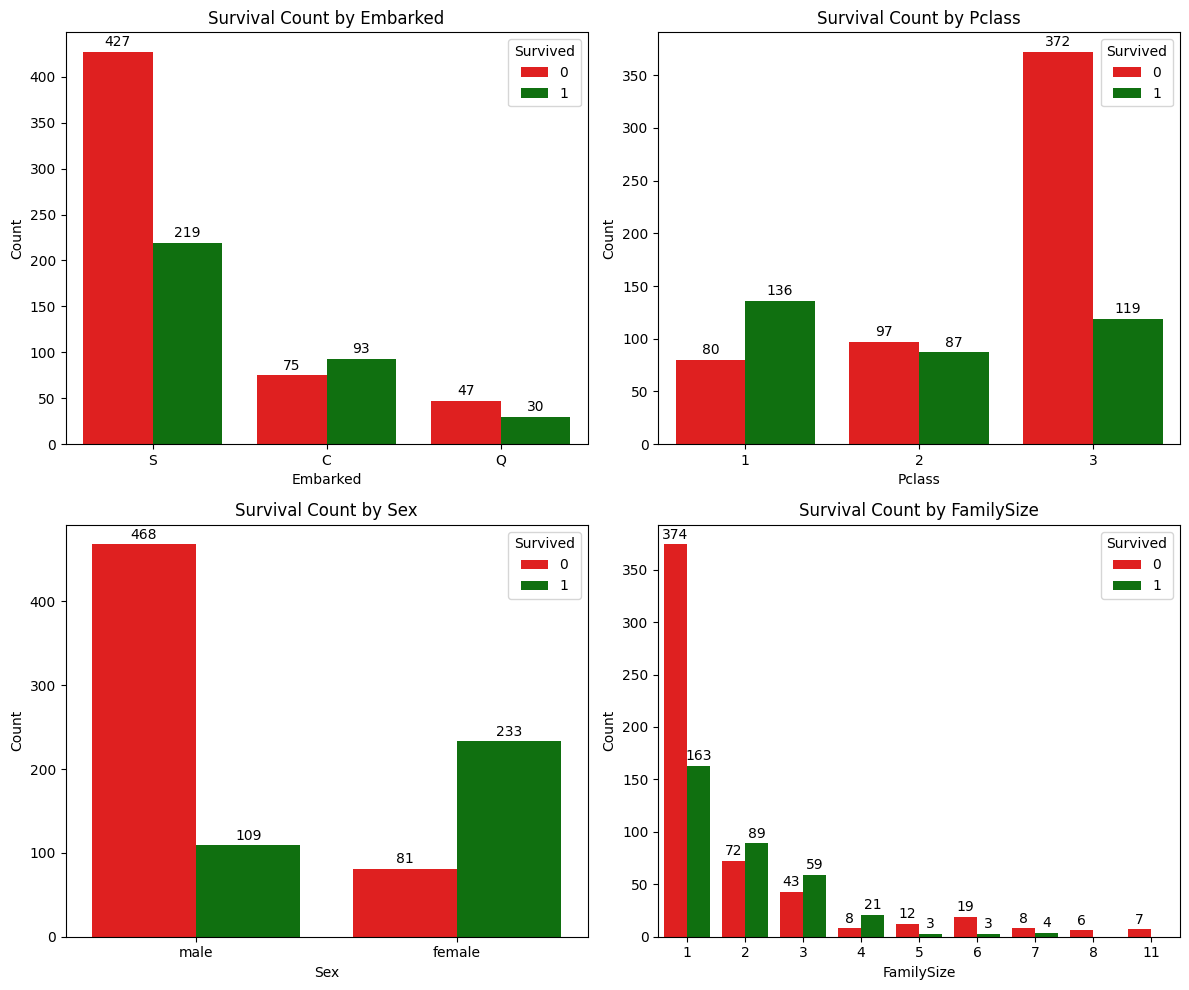

In [18]:
# Visualize the number of survivors and non-survivors by features
plt.figure(figsize=(12, 10))
for i, feature in enumerate(col):
    colors = ['red', 'green']
    ax = plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, hue='Survived', data=titanic_data, palette=colors, ax=ax)
    plt.title(f'Survival Count by {feature}')
    plt.ylabel('Count')
    plt.xlabel(feature)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=2)
plt.tight_layout()
plt.show()

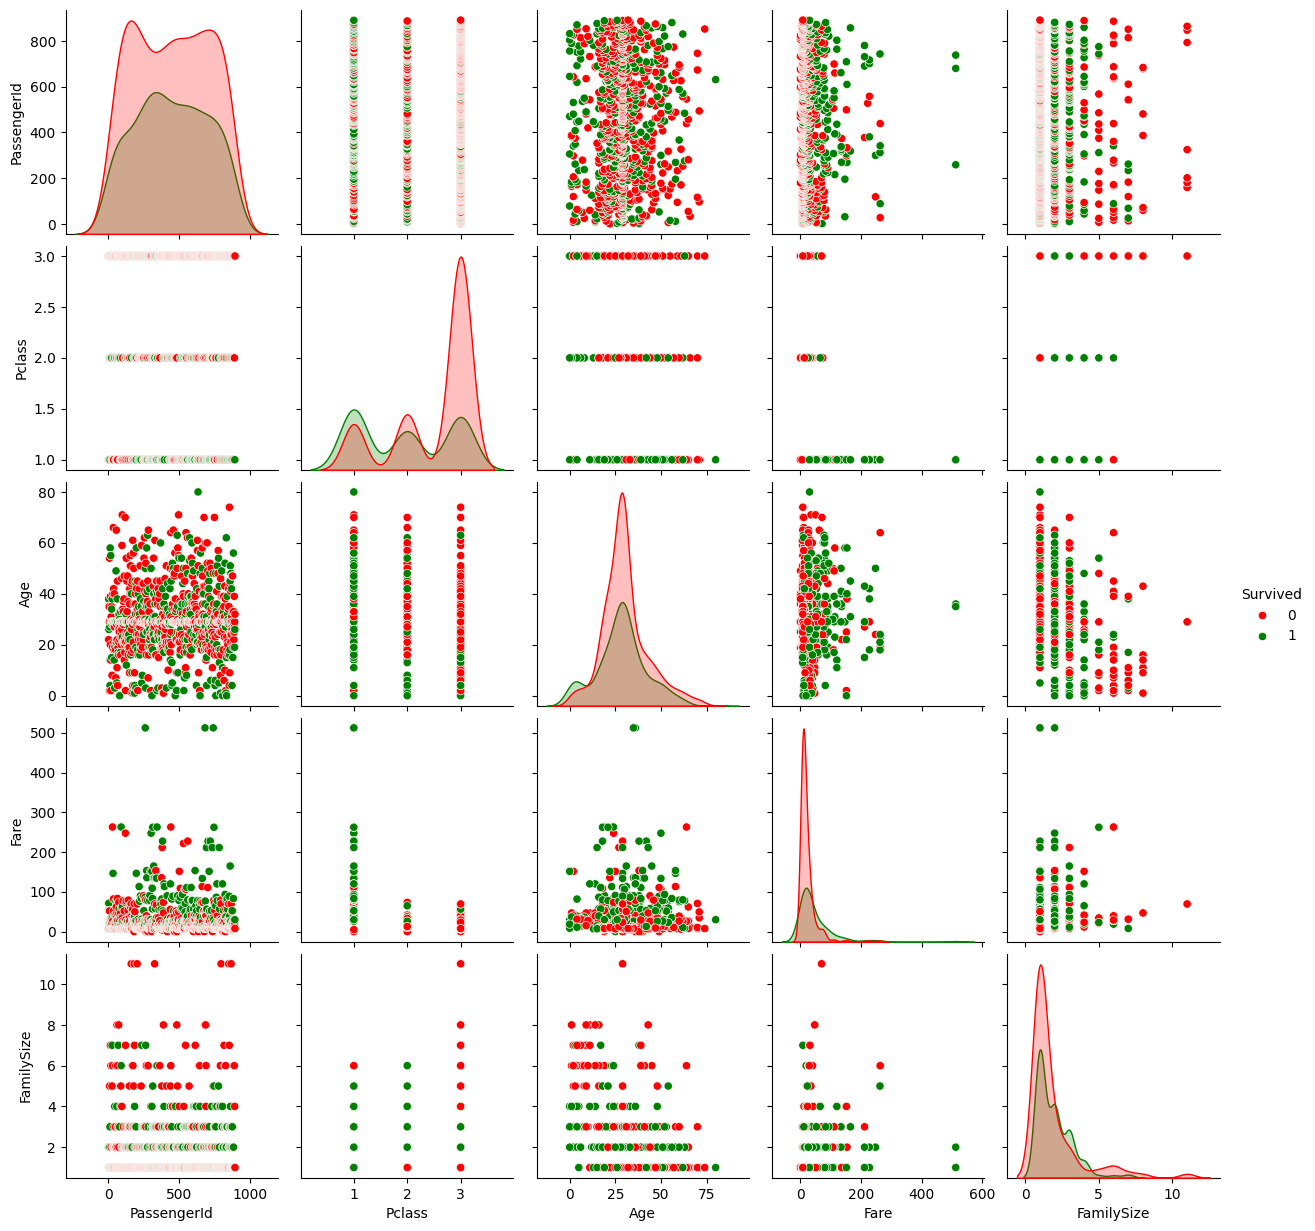

In [19]:
colors = ['red', 'green']
sns.pairplot(titanic_data, hue='Survived', palette=colors)

# Pipeline

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Reload from raw data so the pipeline controls preprocessing and avoids data leakage.
df = pd.read_csv("Titanic-Dataset.csv").copy()

# Feature engineering
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

feature_cols = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "Title"]
X_clean = df[feature_cols]
y_clean = df["Survived"]

num_features = ["Pclass", "Age", "Fare", "FamilySize"]
cat_features = ["Sex", "Embarked", "Title"]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    logistic_pipeline,
    X_train_clean,
    y_train_clean,
    cv=cv,
    scoring="accuracy"
)

logistic_pipeline.fit(X_train_clean, y_train_clean)
y_pred_clean = logistic_pipeline.predict(X_test_clean)

print(f"CV Accuracy (train, 5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_clean, y_pred_clean):.4f}")
print(f"Test Precision: {precision_score(y_test_clean, y_pred_clean):.4f}")
print(f"Test Recall: {recall_score(y_test_clean, y_pred_clean):.4f}")
print(f"Test F1-score: {f1_score(y_test_clean, y_pred_clean):.4f}")
print("\nClassification report:")
print(classification_report(y_test_clean, y_pred_clean))
print("Confusion matrix:")
print(confusion_matrix(y_test_clean, y_pred_clean))

CV Accuracy (train, 5-fold): 0.8203 +/- 0.0247
Test Accuracy: 0.8358
Test Precision: 0.8041
Test Recall: 0.7573
Test F1-score: 0.7800

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       165
           1       0.80      0.76      0.78       103

    accuracy                           0.84       268
   macro avg       0.83      0.82      0.82       268
weighted avg       0.83      0.84      0.83       268

Confusion matrix:
[[146  19]
 [ 25  78]]


# Experimentation

### Linnear Regression Model

In [21]:
# Prepare the data for modeling
X = titanic_data[['Embarked','Pclass','Sex','Age','FamilySize','Title']]
y = titanic_data['Survived']
X = pd.get_dummies(X, columns=['Embarked','Sex','Title'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, np.round(y_pred))

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')     
print(f'Accuracy: {accuracy}')

Mean Absolute Error: 0.27975165892364773
Mean Squared Error: 0.131131265398588
Accuracy: 0.8283582089552238


In [25]:
print(classification_report(y_test, np.round(y_pred)))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       165
           1       0.79      0.75      0.77       103

    accuracy                           0.83       268
   macro avg       0.82      0.81      0.82       268
weighted avg       0.83      0.83      0.83       268



In [26]:
print(confusion_matrix(y_test, np.round(y_pred)))

[[145  20]
 [ 26  77]]


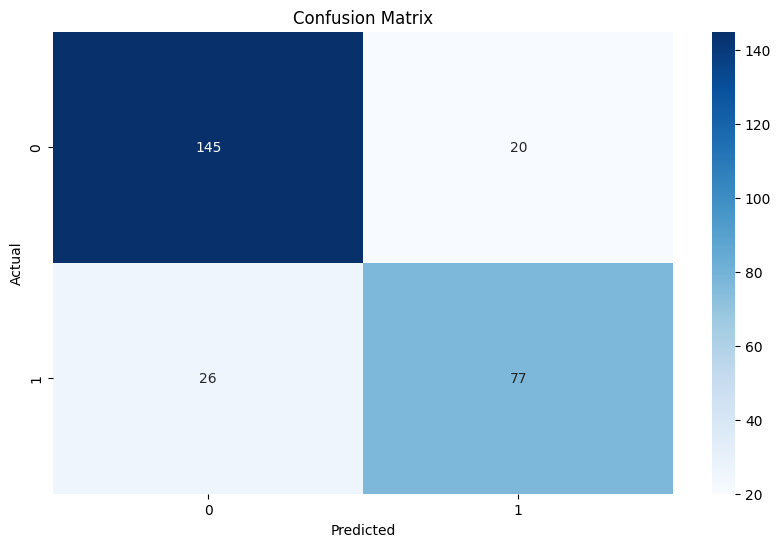

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
y_pred = logistic_model.predict(X_test)

In [30]:
mae_logistic = mean_absolute_error(y_test, y_pred)
mse_logistic = mean_squared_error(y_test, y_pred)
accuracy_logistic = accuracy_score(y_test, np.round(y_pred))

print(f'Mean Absolute Error: {mae_logistic}')
print(f'Mean Squared Error: {mse_logistic}')     
print(f'Accuracy: {accuracy_logistic}')

Mean Absolute Error: 0.19402985074626866
Mean Squared Error: 0.19402985074626866
Accuracy: 0.8059701492537313


In [31]:
print(classification_report(y_test, np.round(y_pred)))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       165
           1       0.76      0.72      0.74       103

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.81      0.80       268



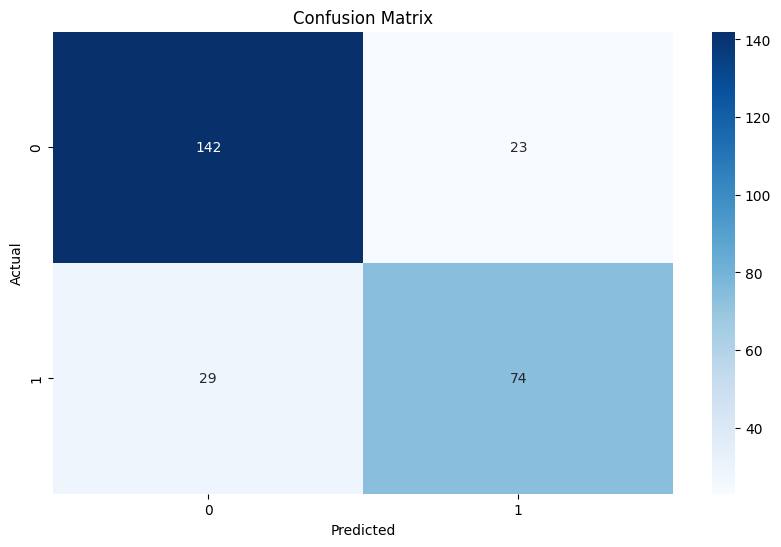

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()